In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler


In [2]:
df = pd.read_csv('data/Test.csv')
df.head()


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6


In [3]:
df = df.dropna()
df = df.drop(columns=['ID','Var_1'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2154 entries, 0 to 2626
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           2154 non-null   object 
 1   Ever_Married     2154 non-null   object 
 2   Age              2154 non-null   int64  
 3   Graduated        2154 non-null   object 
 4   Profession       2154 non-null   object 
 5   Work_Experience  2154 non-null   float64
 6   Spending_Score   2154 non-null   object 
 7   Family_Size      2154 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 151.5+ KB


In [4]:
encoder = LabelEncoder()

object_columns = df.select_dtypes(include=['object']).columns

for col in object_columns:
    df[col] = encoder.fit_transform(df[col])

In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Train clustering model
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels
df['Cluster'] = clusters

# Calculate feature importance
importance = {}

for col in df.columns:
    cluster_means = df.groupby('Cluster')[col].mean()
    importance[col] = np.std(cluster_means)

# Convert to dataframe
importance_df = pd.DataFrame({
    'Feature': importance.keys(),
    'Importance': importance.values()
}).sort_values(by='Importance', ascending=False)

print(importance_df)

           Feature  Importance
2              Age   11.685373
4       Profession    0.829845
8          Cluster    0.816497
6   Spending_Score    0.766352
7      Family_Size    0.604594
5  Work_Experience    0.516853
1     Ever_Married    0.438742
3        Graduated    0.122363
0           Gender    0.052154


In [6]:
# from sklearn.feature_selection import f_classif

# X_features = X_scaled
# y_clusters = clusters

# f_scores, _ = f_classif(X_features, y_clusters)

# importance_df = pd.DataFrame({
#     'Feature':df.columns,
#     'Importance': f_scores
# }).sort_values(by='Importance', ascending=False)

# print(importance_df)



In [7]:
# from sklearn.decomposition import PCA
# import numpy as np

# pca = PCA()
# pca.fit(X_scaled)

# importance = np.abs(pca.components_).mean(axis=0)

# importance_df = pd.DataFrame({
#     'Feature': df.columns,
#     'Importance': importance
# }).sort_values(by='Importance', ascending=False)

# print(importance_df)

In [8]:
df = df.drop(columns=['Gender'])

In [9]:
scaler = MinMaxScaler()
df = scaler.fit_transform(df)

Converged at iteration 2


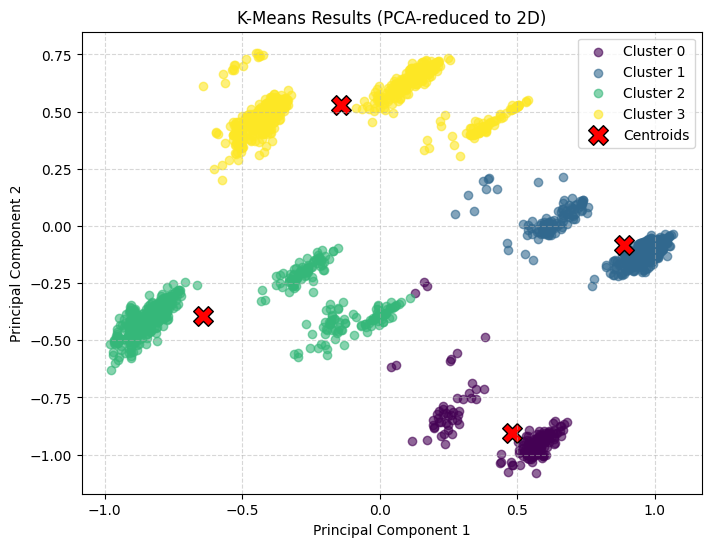

Fitness (Total Cost): 997.4760131107549


In [10]:
from algorithm.k_mean import KMeans as kmeans
model = kmeans(k=4, max_iters=100, tol=1e-7, random_state=42)
labels , fitness = model.fit(df)
model.plot_clusters(df, labels)
print("Fitness (Total Cost):", fitness)

Converged at iteration 4


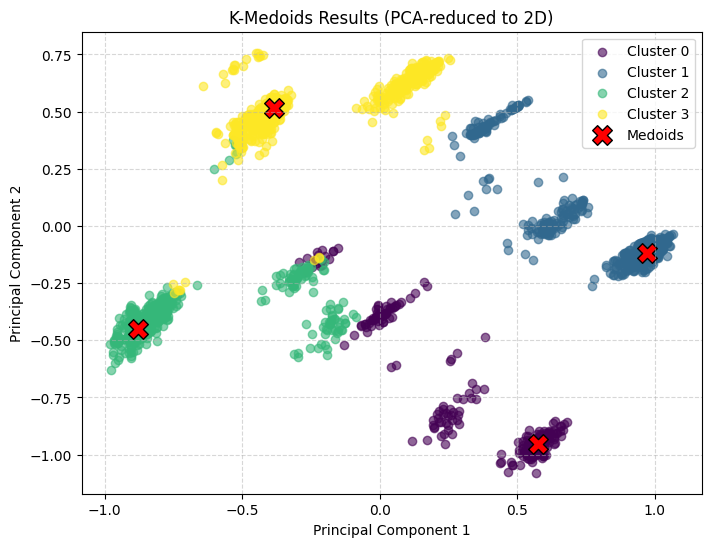

Fitness (Total Cost): 2471.3226861167004


In [11]:
from algorithm.K_Medoids import KMedoids
model = KMedoids(k=4, max_iters=100, tol=1e-7,random_state=42)
labels, fitness = model.fit(df)

model.plot_clusters(df, labels)
print("Fitness (Total Cost):", fitness)

Converged at iteration 41
Fitness (Total Cost): 442.9893775502345


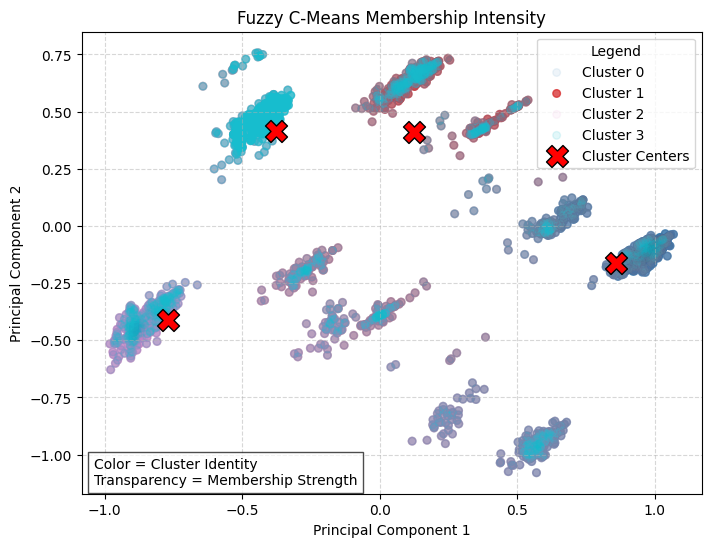

In [12]:
from algorithm.c_means import FuzzyCMeans
model = FuzzyCMeans(k=4, m=2.0, max_iters=100, tol=1e-7, random_state=42)
labels, fitness = model.fit(df)
print("Fitness (Total Cost):", fitness)
model.plot_membership_intensity(df)


EO finished — best WCSS: 1404.3345


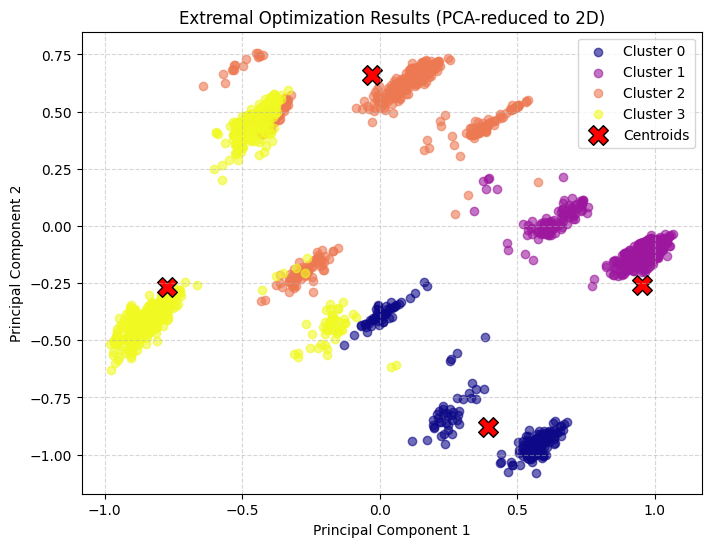

Fitness (Total Cost): 1404.3345280751232


In [13]:
from algorithm.Extremal_Optimization import ExtremalOptimization
model = ExtremalOptimization(k=4, max_iters=100, tau=1.5, perturbation_scale=0.3, random_state=42)
labels, fitness = model.fit(df)
model.plot_clusters(df, labels)
print("Fitness (Total Cost):", fitness)

Fitness (Total Cost): 1220.8374278794006


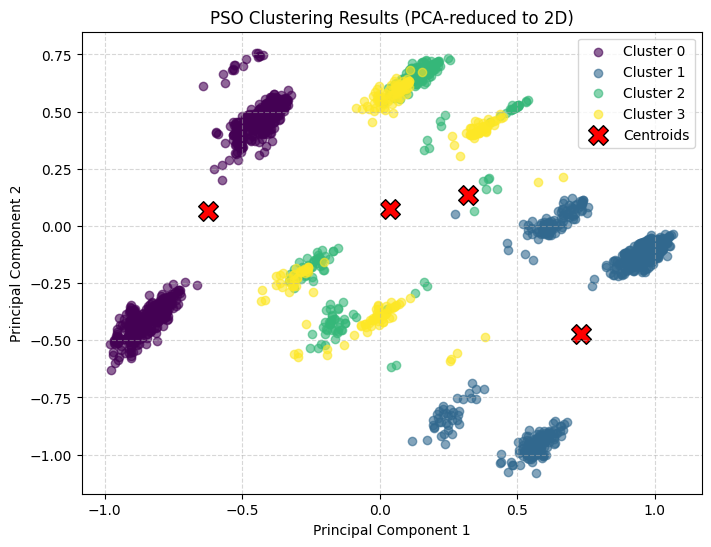

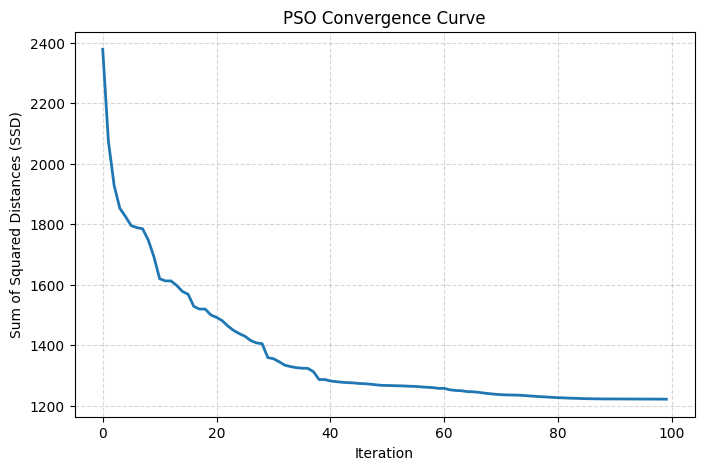

In [14]:
from algorithm.PSO import PSOClustering

pso = PSOClustering(k=4, n_particles=30, max_iters=100, random_state=42)
pso = pso.fit(df)

labels = pso.predict(df)
print("Fitness (Total Cost):", pso.fitness(df, pso.centroids))
pso.plot_clusters(df, labels)
pso.plot_convergence()